# 🎨 Image Generator Starter

**AI Learning Playground — Educational Quickstart Blueprint**

Build, run, and deploy a text-to-image generator using **FLUX.1-dev GGUF** —
a state-of-the-art diffusion transformer that produces photorealistic images in 28 steps.

> ⚠️ **Prerequisite:** Run **[project-setup.ipynb](project-setup.ipynb)** first to install
> dependencies, validate your GPU, authenticate with Hugging Face, and download all models.

---

## What This Notebook Covers

| Step | Topic | Key Concept |
|------|-------|-------------|
| 1 | Configure Settings | Loading `image_gen.yaml`, resolving `image_model_path` |
| 2 | Verify Assets | Confirming FLUX.1-dev GGUF model files are present |
| 3 | Initialize Model | Instantiating `ImageGenModel` (pipeline loads lazily) |
| 4 | Demo | Calling `model.predict()` → base64 image → display in notebook |
| 5 | GPU Monitoring | VRAM usage during diffusion pipeline |
| 6 | Register Model | Logging to MLflow as `AIStudio-EQ-ImageGen` |
| 7 | Verify | Loading registered model and running a test inference |

## How FLUX.1-dev Works

```
Text Prompt
     ↓  Text encoders (CLIP + T5-XXL)
Text embeddings
     ↓  Multimodal Diffusion Transformer (GGUF quantized, 28 denoising steps)
Latent representation
     ↓  VAE decoder
PIL Image  →  base64 PNG  →  model.predict() output
```

FLUX.1-dev uses a **Multimodal Diffusion Transformer (MMDiT)** architecture that jointly
processes text and image tokens, achieving superior prompt following and image quality.
The GGUF-quantized transformer dramatically reduces VRAM requirements vs. fp16 weights.

<div class="alert alert-block alert-warning">
<b>⚠️ Responsible AI Notice — Guardrails Not Included:</b> This notebook generates images from text prompts using <b>FLUX.1-dev GGUF</b>. Diffusion models can produce <b>misleading, inappropriate, or harmful imagery</b> depending on the prompt. Validate prompts and screen generated images before exposing this pipeline to users.
<br><br>
<b>💡 Tip:</b> This notebook does not include guardrails. To add prompt and output safety to your image generation pipeline, consider these open-source tools:
<ul>
  <li><a href="https://github.com/huggingface/diffusers"><b>Diffusers Safety Checker</b></a> — Built-in NSFW image classifier included in Hugging Face diffusion pipelines; a drop-in addition to your pipeline.</li>
  <li><a href="https://github.com/NVIDIA/NeMo-Guardrails"><b>NeMo Guardrails</b></a> — Apply input rails on text prompts to block unsafe or policy-violating generation requests before they reach the model.</li>
  <li><a href="https://github.com/protectai/llm-guard"><b>LLM Guard</b></a> — Screen text prompts for harmful language and jailbreak attempts before they are passed to the diffusion pipeline.</li>
  <li><a href="https://github.com/guardrails-ai/guardrails"><b>Guardrails AI</b></a> — Define prompt validators that flag or rewrite unsafe inputs before image generation begins.</li>
</ul>
</div>

In [1]:
import os
import sys
import time
import logging
import warnings
import plotly.io as pio

sys.path.insert(0, "..")

# ── Warning & logging suppression ─────────────────────────────────────────────
# These lines hide informational noise (deprecation notices, version-mismatch
# alerts) so the notebook output stays clean and focused on what you're learning.
# As a learning exercise, try commenting them out one at a time to see what
# each library would normally print during model loading and inference.
os.environ["MLFLOW_LOGGING_LEVEL"] = "ERROR"  # must be set before `import mlflow`
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

pio.renderers.default = "plotly_mimetype+notebook"

start_time = time.time()
print("⏱️  Notebook started")

⏱️  Notebook started


## 2. Configure Settings

Load `configs/image_gen.yaml` which specifies `capability: image_gen`
and the path to the FLUX.1-dev model directory.

In [2]:
import os
from src.utils import load_config

config = load_config("../configs/image_gen.yaml")

image_model_path = config.get("model_path", "/home/jovyan/local/flux1-dev")


print(f"Capability       : {config.get('capability')}")
print(f"Image model path : {image_model_path}")
print(f"Model exists     : {'✅' if os.path.exists(image_model_path) else '❌ Not found'}")
print(f"UI mode          : {config.get('ui', {}).get('mode', 'streamlit')}")

Capability       : image_gen
Image model path : /home/jovyan/local/flux1-dev
Model exists     : ✅
UI mode          : streamlit


## 2. Verify Assets

Confirm the FLUX.1-dev GGUF transformer and pipeline files are present before loading.

The FLUX.1-dev model directory (`image_model_path`) contains:
- `flux1-dev-Q4_K_S.gguf` — the quantized transformer (loaded via `FluxTransformer2DModel.from_single_file`)
- `model_index.json` + other pipeline components (text encoders, VAE, scheduler) — downloaded by `project-setup.ipynb`

In [3]:
import os
from src.utils import log_asset_status

gguf_path      = os.path.join(image_model_path, "flux1-dev-Q4_K_S.gguf")
pipeline_index = os.path.join(image_model_path, "model_index.json")

assets = [
    {"name": "FLUX GGUF transformer",  "path": gguf_path,                          "required": True},
    {"name": "FLUX pipeline index",    "path": pipeline_index,                     "required": True},
    {"name": "Config YAML",            "path": "../configs/image_gen.yaml",         "required": True},
    {"name": "Image gen demo UI",      "path": "../demo/image_gen/streamlit/main.py",         "required": False},
]

log_asset_status(assets)


## 4. Initialize ImageGenModel

Instantiate `ImageGenModel` — the same class registered in MLflow.

**Lazy loading design:**
The diffusion pipeline (several GB in memory) is NOT loaded in `__init__`.
It is loaded on the first `predict()` call and cached for subsequent calls.
This keeps initialization fast and avoids loading unused models.

In [4]:
from src.mlflow.models.image_gen import ImageGenModel
from src.gpu_monitor import GPUMonitor

print("Initializing ImageGenModel...")
print("(Pipeline loads lazily on first predict() call)")

model = ImageGenModel(
    config=config,
)
monitor = GPUMonitor()

print("\n✅ ImageGenModel ready")
print(f"   Image model path : {model.model_path}")


Initializing ImageGenModel...
(Pipeline loads lazily on first predict() call)

✅ ImageGenModel ready
   Image model path : /home/jovyan/local/flux1-dev


## 5. Demo: Text-to-Image Generation

Call `model.predict()` with a prompt and optional generation parameters.

`ImageGenModel` accepts these columns:

| Column | Type | Default | Description |
|---|---|---|---|
| `prompt` | str | — | Text description of the image to generate |
| `num_inference_steps` | int | 28 | Denoising steps — more = better quality, slower |
| `guidance_scale` | float | 3.5 | How strongly the model follows the prompt (1–10) |
| `height` | int | 1024 | Output image height in pixels |
| `width` | int | 1024 | Output image width in pixels |
| `seed` | int | -1 | Fixed seed for reproducibility; `-1` = random |

The `answer` output is a base64-encoded PNG — decoded and displayed inline.

Generating: 'A futuristic AI robot teaching in a university classroom, ph...'
  steps=28  guidance=3.5  1024×1024px  random seed


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


  0%|          | 0/28 [00:00<?, ?it/s]

✅ Generated in 68.9s


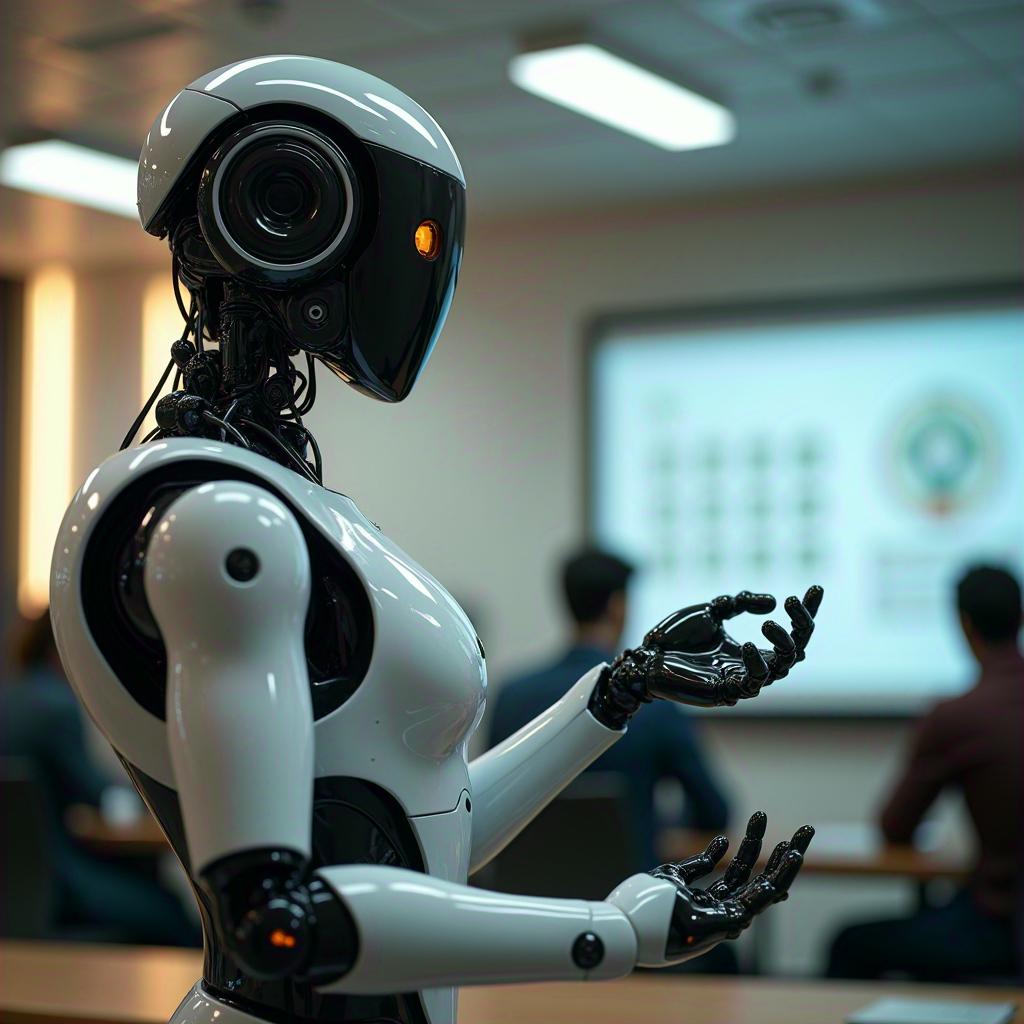

In [5]:
import base64
import pandas as pd
from IPython.display import Image as IPImage, display

def generate_and_display(
    prompt: str,
    num_inference_steps: int = 28,
    guidance_scale: float = 3.5,
    height: int = 1024,
    width: int = 1024,
    seed: int = -1,
) -> None:
    """
    Generate an image and display it inline in the notebook.

    Args:
        prompt:               Text description of the image.
        num_inference_steps:  Denoising steps (10–50). More = better quality, slower.
        guidance_scale:       Prompt adherence weight (1.0–10.0). 3–5 typical for FLUX.
        height / width:       Output resolution in pixels. FLUX native = 1024.
        seed:                 Fixed seed for reproducibility. -1 = random.

    Why pass generation params via `params={}` instead of extra DataFrame columns?
        MLflow's signature validation strips any column that is not declared in the
        model's input_schema before calling predict(). Only `prompt` is schema-declared,
        so extra columns would be silently dropped with a warning.
        The `params` dict bypasses schema validation and is always forwarded intact —
        it is the correct MLflow-native way to pass optional/defaulted batch inputs.
    """
    seed_label = f"seed={seed}" if seed >= 0 else "random seed"
    print(
        f"Generating: '{prompt[:60]}...'\n"
        f"  steps={num_inference_steps}  guidance={guidance_scale}"
        f"  {width}×{height}px  {seed_label}"
    )
    t0 = __import__('time').time()

    result = model.predict(
        pd.DataFrame([{"prompt": prompt}]),
        params={
            "num_inference_steps": num_inference_steps,
            "guidance_scale":      guidance_scale,
            "height":              height,
            "width":               width,
            "seed":                seed,
        },
    )
    elapsed = __import__('time').time() - t0
    answer = result["answer"].iloc[0]

    # Latent-token proxy: image latent patches for GPU monitor logging
    monitor.log_inference(num_tokens=height * width // 64, elapsed_seconds=elapsed)

    if len(answer) > 200 and not answer.startswith("❌"):
        img_bytes = base64.b64decode(answer)
        print(f"✅ Generated in {elapsed:.1f}s")
        display(IPImage(data=img_bytes, width=min(width, 768)))
    else:
        print(f"Error: {answer}")

# First generation — also loads the pipeline into VRAM (takes longer on first run)
generate_and_display(
    "A futuristic AI robot teaching in a university classroom, photorealistic, warm lighting, high detail"
)

Generating: 'Abstract visualization of a neural network, glowing blue nod...'
  steps=20  guidance=4.0  512×512px  random seed


  0%|          | 0/20 [00:00<?, ?it/s]

✅ Generated in 16.1s


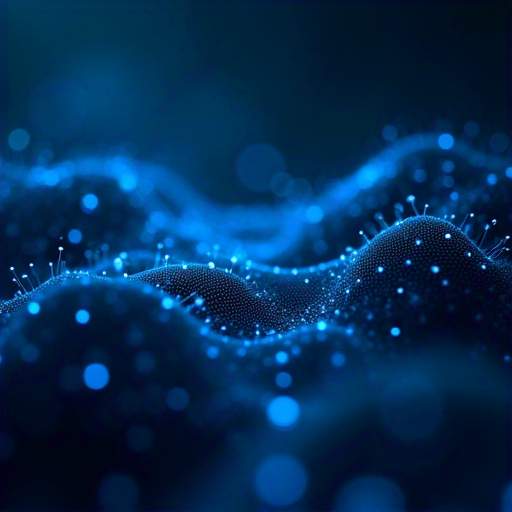

In [6]:
# Second generation — pipeline already warm, much faster.
# Fewer steps + lower resolution = fastest possible result for quick iteration.
generate_and_display(
    "Abstract visualization of a neural network, glowing blue nodes and connections, dark background, digital art",
    num_inference_steps=20,
    guidance_scale=4.0,
    height=512,
    width=512,
)

In [7]:
import time
import plotly.graph_objects as go

# Benchmark: measure generation time across multiple prompts with consistent params.
# Using 512×512 + 20 steps to keep the benchmark fast.
bench_prompts = [
    "A scenic mountain landscape at sunrise",
    "Abstract data visualization with colorful charts",
    "A circuit board with glowing components, macro photography",
]
BENCH_PARAMS = {
    "num_inference_steps": 20,
    "guidance_scale":      3.5,
    "height":              512,
    "width":               512,
    "seed":                0,   # Fixed seed for reproducible benchmarks
}

times = []
for p in bench_prompts:
    t0 = time.time()
    res = model.predict(pd.DataFrame([{"prompt": p}]), params=BENCH_PARAMS)
    elapsed = time.time() - t0
    times.append(elapsed)
    monitor.log_inference(num_tokens=512 * 512 // 64, elapsed_seconds=elapsed)

fig = go.Figure(go.Bar(
    x=[f"Prompt {i+1}" for i in range(len(bench_prompts))],
    y=times,
    marker_color="#0096d6",
    text=[f"{t:.1f}s" for t in times],
    textposition="auto",
))
fig.update_layout(
    title=(
        f"Image Generation Time "
        f"({BENCH_PARAMS['num_inference_steps']} steps, "
        f"{BENCH_PARAMS['width']}×{BENCH_PARAMS['height']}px)"
    ),
    xaxis_title="Prompt",
    yaxis_title="Time (seconds)",
    template="plotly_white",
)
fig.show()

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

## 6. GPU Monitoring

FLUX.1-dev uses significantly more VRAM than the chatbot (GGUF transformer + text encoders + VAE loaded).
Observe how the diffusion pipeline occupies GPU memory.

In [8]:
monitor.display_dashboard()


## 7. Register with MLflow

Register this model as **`AIStudio-EQ-ImageGen`**. 

The `configs/image_gen.yaml` has `capability: image_gen` so `loader.py` will
automatically select `ImageGenModel` when this registered model is loaded or served.

In [9]:
import mlflow

from src.utils import release_model_vram
release_model_vram(model, label="ImageGenModel") # Release memory from the model before loading the registered model.

EXPERIMENT_NAME = 'ImageGeneration-StarterExperiment'

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "/phoenix/mlflow"))
mlflow.set_experiment(experiment_name= EXPERIMENT_NAME)

ARTIFACT_PATH = "AIStudio-EQ-ImageGen"
MODEL_NAME    = "AIStudio-EQ-ImageGen"

print(f"Artifact path  : {ARTIFACT_PATH}")
print(f"Registered as  : {MODEL_NAME}")
print(f"Tracking URI   : {mlflow.get_tracking_uri()}")

🧹 Releasing VRAM for: ImageGenModel ...
✅ Done — VRAM: 0.0 GB / 47.4 GB (0% used)
Artifact path  : AIStudio-EQ-ImageGen
Registered as  : AIStudio-EQ-ImageGen
Tracking URI   : /phoenix/mlflow


In [10]:
from mlflow.models import ModelSignature
from mlflow.types.schema import ColSpec, Schema,ParamSchema, ParamSpec

# Input schema — only `prompt` is declared as required.
# MLflow treats every schema column as *required* and raises MlflowException
# if any are missing, so optional parameters must NOT be listed as ColSpec.
input_schema = Schema([
    ColSpec("string", "prompt"),  # Required: text description of the image
])

output_schema = Schema([
    ColSpec("string", "answer"),    # Base64-encoded PNG image
    ColSpec("string", "messages"),  # JSON metadata including params used
])

# ParamSchema declares optional parameters with default values.
# Without this, MLflow ignores any params={} passed to predict() and logs a warning.
# These params are forwarded intact to predict() — both in direct notebook calls
# and via the HTTP /invocations endpoint — without being subject to schema validation.
params_schema = ParamSchema([
    ParamSpec("num_inference_steps", "long",   28),    # Denoising steps (10–50)
    ParamSpec("guidance_scale",      "double",  3.5),  # Prompt adherence (1.0–10.0)
    ParamSpec("height",              "long",   1024),  # Output height in pixels
    ParamSpec("width",               "long",   1024),  # Output width in pixels
    ParamSpec("seed",                "long",   -1),    # -1 = random; ≥0 = fixed seed
])

signature = ModelSignature(
    inputs=input_schema,
    outputs=output_schema,
    params=params_schema,
)

print("Input  :", signature.inputs.to_dict())
print("Params :", signature.params.to_dict())
print("Output :", signature.outputs.to_dict())

Input  : [{'type': 'string', 'name': 'prompt', 'required': True}]
Params : [{'name': 'num_inference_steps', 'default': 28, 'shape': None, 'type': 'long'}, {'name': 'guidance_scale', 'default': 3.5, 'shape': None, 'type': 'double'}, {'name': 'height', 'default': 1024, 'shape': None, 'type': 'long'}, {'name': 'width', 'default': 1024, 'shape': None, 'type': 'long'}, {'name': 'seed', 'default': -1, 'shape': None, 'type': 'long'}]
Output : [{'type': 'string', 'name': 'answer', 'required': True}, {'type': 'string', 'name': 'messages', 'required': True}]


In [11]:
from src.mlflow.logger import Logger

print(f"✅ Registering Model  : {MODEL_NAME}")

with mlflow.start_run(run_name=f"register-{ARTIFACT_PATH}") as run:
    Logger.log_model(
        signature     = signature,
        artifact_path = ARTIFACT_PATH,
        config_path   = "../configs/image_gen.yaml",
        model_paths   = {"model_path": image_model_path},
        demo_folder   = "../demo/image_gen",
    )
    run_id = run.info.run_id

print(f"✅ Model logged | Run ID: {run_id}")

model_uri = f"runs:/{run_id}/{ARTIFACT_PATH}"
reg = mlflow.register_model(model_uri=model_uri, name=MODEL_NAME)

print(f"✅ Registered  : {MODEL_NAME} v{reg.version}")


✅ Registering Model  : AIStudio-EQ-ImageGen
✅ Model logged | Run ID: 8c6c11e1368645158fe13783bdda2a83
✅ Registered  : AIStudio-EQ-ImageGen v1


Successfully registered model 'AIStudio-EQ-ImageGen'.
Created version '1' of model 'AIStudio-EQ-ImageGen'.


## 8. Verify Registration

Load the registered model and confirm it generates an image successfully.

🚀 Starting isolated subprocess for MLflow inference...


`torch_dtype` is deprecated! Use `dtype` instead!


<IPython.core.display.HTML object>


100%|██████████| 20/20 [00:14<00:00,  1.35it/s]
[W312 14:21:33.148865349 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())


✅ Registered model generated an image successfully


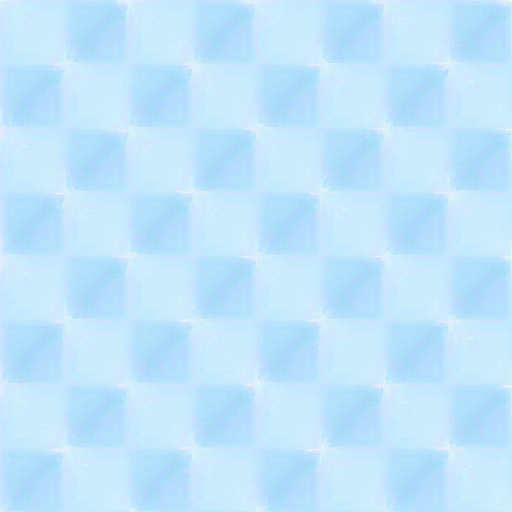

In [12]:
import base64
import pandas as pd
from IPython.display import Image as IPImage, display
from src.utils import run_isolated_mlflow_predict

# Run the registered model in an isolated subprocess.
# When the subprocess exits, the CUDA driver reclaims all VRAM automatically —
# no manual del / gc.collect / empty_cache needed.
test_result = run_isolated_mlflow_predict(
    model_uri=model_uri,
    input_df=pd.DataFrame([{"prompt": "A simple geometric pattern, blue and white, minimalist"}]),
    params={
        "num_inference_steps": 20,
        "guidance_scale":      3.5,
        "height":              512,
        "width":               512,
        "seed":                0,
    },
)

answer = test_result["answer"].iloc[0]
if len(answer) > 200 and not answer.startswith("❌"):
    img_bytes = base64.b64decode(answer)
    print("✅ Registered model generated an image successfully")
    display(IPImage(data=img_bytes, width=256))
else:
    print(f"Response: {answer}")


In [13]:
elapsed = time.time() - start_time
print(f"⏱️  Total notebook time: {elapsed:.1f}s ({elapsed / 60:.1f} min)")

⏱️  Total notebook time: 245.8s (4.1 min)


---

## ✅ What We Accomplished

| Step | Result |
|------|--------|
| Environment | CUDA verified, VRAM checked |
| ImageGenModel | Initialized with FLUX.1-dev GGUF (lazy pipeline loading) |
| Demo | Generated and displayed multiple images inline |
| GPU Monitor | VRAM usage during diffusion visible |
| Registration | `AIStudio-EQ-ImageGen` registered in Model Registry |
| Verification | Loaded model generated test image |

## Next Steps

- **Explore another capability:** Open `document-analyzer-starter.ipynb`
- **Deploy in AI Studio:** Select `AIStudio-EQ-ImageGen` → click Deploy → use the image gen Streamlit UI
- **Try different prompts:** Experiment with style keywords: `photorealistic`, `oil painting`, `watercolor`, `digital art`
- **Adjust quality vs. speed:** Edit `num_inference_steps` in `ImageGenModel._generate()` (1–8 steps)